## Introduction

In the era of commercial space, companies are making space travel affordable for everyone. The most successful among them is SpaceX. ​SpaceX’s accomplishments include: 
- ​Sending spacecraft to the International Space Station. 
- ​Starlink, a satellite internet constellation providing satellite Internet access. 
- ​Sending manned missions to Space. 

​One reason SpaceX can do this is the rocket launches are relatively inexpensive. ​SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; ​other providers cost upwards of 165 million dollars each, much of the savings is because ​SpaceX can reuse the first stage. 

​Spaces X’s Falcon 9 launch like regular rockets. ​The payload is enclosed in the fairings - a protective, clamshell-like nose cone atop a launch vehicle. ​Stage two, or the second stage, helps bring the payload to orbit, but most of the work ​is done by the first stage. ​This stage does most of the work and is much larger than the second stage. ​This stage is quite large and expensive. 

​Unlike other rocket providers, SpaceX's Falcon 9 can recover the first stage. ​Sometimes the first stage does not land, it will crash while other times, Space X will sacrifice the first stage due to the mission parameters like ​payload, orbit, and customer. 

## Business Problem

We will determine if SpaceX will reuse the first stage. ​Instead of using rocket science to determine if the first stage will land successfully, we will train a machine learning model and use public information to predict if SpaceX ​will reuse the first stage. If we can determine, if the first stage will land, we can determine the cost ​of a launch. 

## Data Collection

The original project demonstrates data collection using the SpaceX REST API and supplementary information from Wikipedia. At the time of reproducing this analysis, the API responses and website structure had changed, making it difficult to recreate the exact dataset used in the original labs. Therefore, the cleaned dataset provided as part of the capstone resources was used for the subsequent analysis.

### Feature Description
| **Variable**       | **Description**                                                                                                                                                                                    |
| ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **FlightNumber**   | Represents the chronological sequence of SpaceX launches. Higher flight numbers correspond to later missions and may reflect increasing operational experience and technological improvements.     |
| **Year**           | The calendar year in which the launch took place. This feature can help identify temporal trends in launch and landing performance.                                                                |
| **BoosterVersion** | The variant or model of the Falcon 9 first-stage booster used for the mission. Different versions incorporate design improvements that may influence landing success.                              |
| **PayloadMass**    | The total mass (in kilograms) of the payload carried by the rocket. Heavier payloads may affect the amount of fuel available for first-stage recovery and landing.                                 |
| **Orbit**          | The target orbit for the mission (e.g., LEO, GTO, ISS). Different mission profiles require different flight trajectories and fuel requirements, which can influence landing outcomes.              |
| **LaunchSite**     | The launch facility from which the mission was conducted. Different launch sites support different mission types and recovery strategies.                                                          |
| **Outcome**        | The outcome of the first-stage landing attempt, indicating whether the booster was successfully recovered or the recovery attempt failed. This is the target variable for the classification task. |
| **Flights**        | The total number of flights completed by the booster, including the current mission. This feature reflects the operational experience of the booster.                                              |
| **GridFins**       | Indicates whether aerodynamic grid fins were deployed during the booster's descent. Grid fins provide steering and stability, enabling controlled landings.                                        |
| **Reused**         | Indicates whether the first-stage booster had been flown on a previous mission before the current launch. This feature helps assess the impact of booster reusability on landing success.          |
| **Legs**           | Indicates whether landing legs were deployed during the recovery attempt. Landing legs are essential for performing a vertical landing.                                                            |
| **LandingPad**     | The designated landing location for the first-stage booster, such as a ground landing zone or autonomous drone ship. Landing location may influence recovery success.                              |
| **Block**          | The Falcon 9 Block version of the booster, representing a major hardware configuration or upgrade level. Later Block versions generally include improved reliability and reusability.              |
| **ReusedCount**    | The number of previous missions completed by the booster before the current launch. A value of 0 indicates the booster is flying for the first time.                                               |
| **Serial**         | The unique serial identifier assigned to the first-stage booster. This identifier distinguishes individual boosters but does not provide predictive information by itself.                         |
| **Longitude**      | The geographic longitude of the launch site, expressed in decimal degrees. Used primarily for mapping and spatial visualization.                                                                   |
| **Latitude**       | The geographic latitude of the launch site, expressed in decimal degrees. Used primarily for mapping and spatial visualization.                                                                    |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv(r'data\dataset_part_1.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     str    
 2   BoosterVersion  90 non-null     str    
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     str    
 5   LaunchSite      90 non-null     str    
 6   Outcome         90 non-null     str    
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     str    
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     str    
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
dtypes: bool(3), float64(4), int64(3), str(7)
memory 

#### Observation:
The dataset contains missing values only for the `'LandingPad'` which is valid and does not require any imputation

## Data Wrangling

### Data Cleaning
- Before building predictive models, the dataset needs to be cleaned and prepared. This includes selecting relevant features, and creating the target variable required for classification. 
- The dataset was examined for missing values and data types before feature engineering. Since only the `LandingPad` column contained missing values, no further imputation was required because missing values represented missions without a designated landing pad. The target variable (`Class`) was then created from the Outcome column, followed by extracting the launch year from the mission date for temporal analysis.

Since the `Outcome` column contains detailed landing descriptions, it is converted into a binary target variable named `Class`. Successful landings are encoded as 1, while unsuccessful landings are encoded as 0 to support binary classification.

In [4]:
df['Class'] = [1 if 'True' in x else 0  for x in df['Outcome']]

As the exact date of the launch is not necessary but the year will be helpful to understand the number of launches in a year or the success rate over the years. Therfore transforming the `Date` column to year format and renaming the `Date` to `Year`

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.year
df.rename(columns={'Date':'Year'}, inplace=True)
df.head()

,FlightNumber,Year,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## EDA
The objective of the exploratory analysis is to understand how mission characteristics influence first-stage landing success. The following visualizations examine the relationship between launch history, payload characteristics, launch site, orbit type with the landing outcome.

### Visual Analysis

#### 1. Flight Number Vs Payload Mass

To better understand the relationship between payload mass and landing outcome, a scatter plot is used to visualize the payload carried by each flight against its flight number. Each point represents a mission, with colors indicating whether the landing was successful or failed. This visualization helps identify trends, patterns, and any potential relationship between payload mass and landing performance over time.

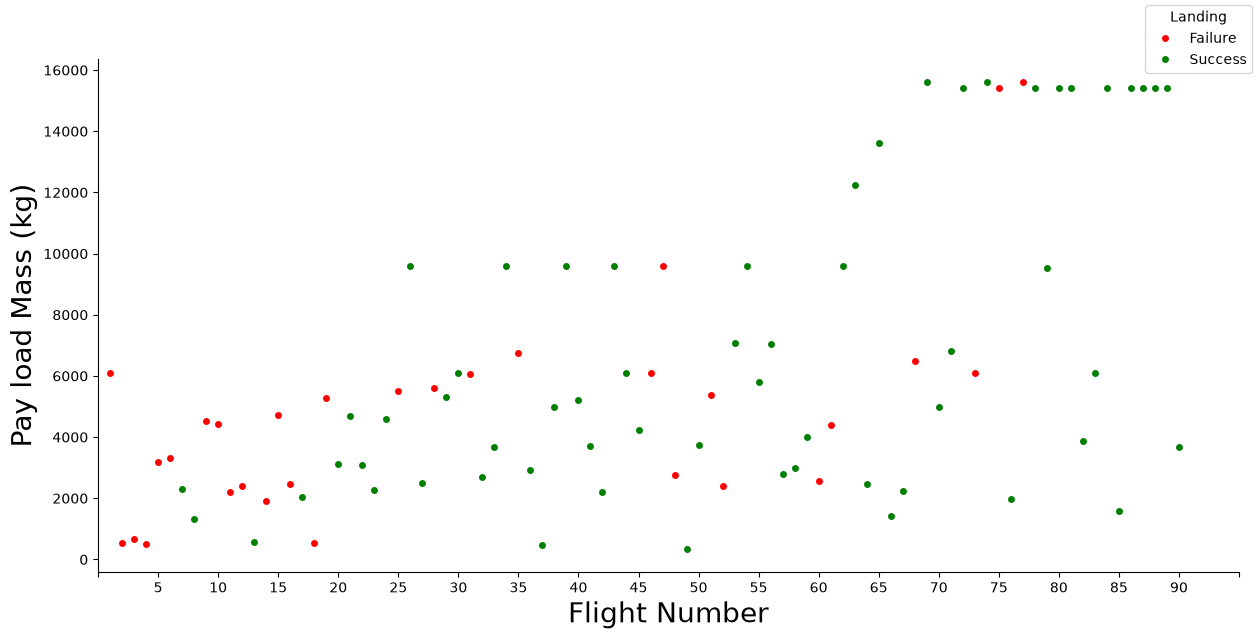

In [6]:
fig1 = sns.catplot(df, x='FlightNumber', y='PayloadMass', hue='Class', height=6, aspect=2, palette=['red', 'green'])
fig1.set_xlabels("Flight Number",fontsize=20)
fig1.set_ylabels("Pay load Mass (kg)",fontsize=20)
# # fig1.ax.set_xticks([10,20,30,40,50,60,70,80,90])
# # fig1.ax.set_xlim(0,90)
# fig1.set(xlim=(0, 91), xticks=[0,10, 20, 30, 40, 50, 60, 70, 80, 90,100])
fig1._legend.set_title('Landing')
fig1._legend.texts[0].set_text('Failure')
fig1._legend.texts[1].set_text('Success')
fig1._legend.set_bbox_to_anchor((1,1))
fig1._legend.set_loc('center right')
fig1._legend.set_frame_on(True)

plt.xlim(-1,90)
plt.xticks(range(-1,95, 5))
plt.tight_layout()

#### Observations

- Successful landings (green) are more frequent than failed landings (red).
- Both successes and failures occur across most payload ranges, especially between **2,000–7,000 kg**.
- Most of the **highest payload missions (above 12,000 kg)** ended in successful landings.
- Later flights generally show more successful landings than earlier flights.

#### Insights

- **Payload mass alone does not strongly influence landing success.**
- Landing performance appears to improve over time, indicating increased mission reliability.
- The success of high-payload missions suggests advancements in rocket recovery and operational capabilities.
- Other factors besides payload mass are likely responsible for landing failures.

#### 2. Flight Number Vs Launch Site

The following scatter plot shows the launch site used for each flight and its corresponding landing outcome. By visualizing launch sites across flight numbers, we can explore whether certain launch locations have higher landing success rates and observe how mission performance has evolved over time.

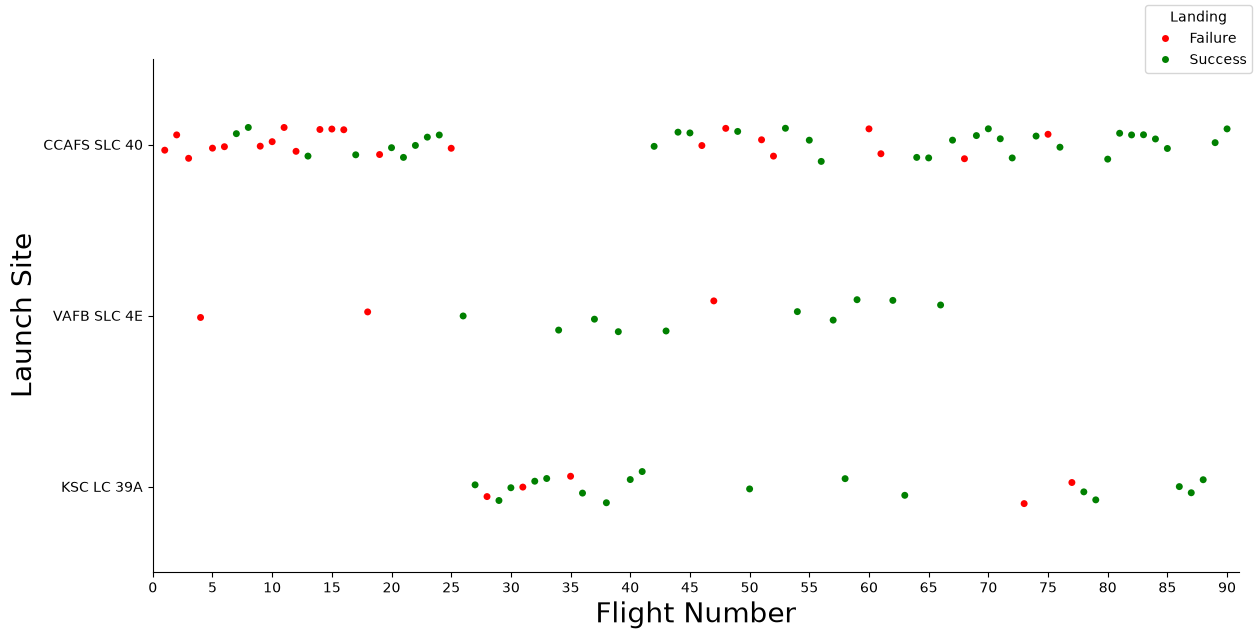

In [7]:
fig2 = sns.catplot(df, x='FlightNumber', y='LaunchSite', hue='Class', height=6, aspect=2, palette=['red', 'green'])
fig2.set_xlabels("Flight Number",fontsize=20)
fig2.set_ylabels("Launch Site",fontsize=20)
fig2._legend.set_title('Landing')
fig2._legend.texts[0].set_text('Failure')
fig2._legend.texts[1].set_text('Success')
fig2._legend.set_bbox_to_anchor((1,1))
fig2._legend.set_loc('center right')
fig2._legend.set_frame_on(True)
plt.xlim(0,91)
plt.xticks(range(0,95, 5))
plt.tight_layout()

#### Observations

- Flights were launched from three sites: **CCAFS SLC 40**, **KSC LC 39A**, and **VAFB SLC 4E**.
- **CCAFS SLC 40** hosted the largest number of launches.
- Successful landings (green) become more frequent in later flights across all launch sites.
- All launch sites experienced both successful and failed landings.
- **KSC LC 39A** and **VAFB SLC 4E** show a higher proportion of successful landings compared to failures.

#### Insights

- Landing success improved over time regardless of the launch site.
- **CCAFS SLC 40** had the most launches, making it the primary launch site.
- No launch site consistently resulted in failures, indicating that launch location alone does not determine landing success.
- The increasing number of successful landings across all sites suggests improvements in rocket recovery technology and mission operations.

#### 3. Payload Mass Vs Launch Site

The following scatter plot illustrates the relationship between **payload mass** and **launch site**, with each point representing a mission and its corresponding landing outcome. By comparing payload masses across different launch sites, we can identify whether certain sites handle heavier payloads more successfully and explore if payload size has any noticeable impact on landing success.

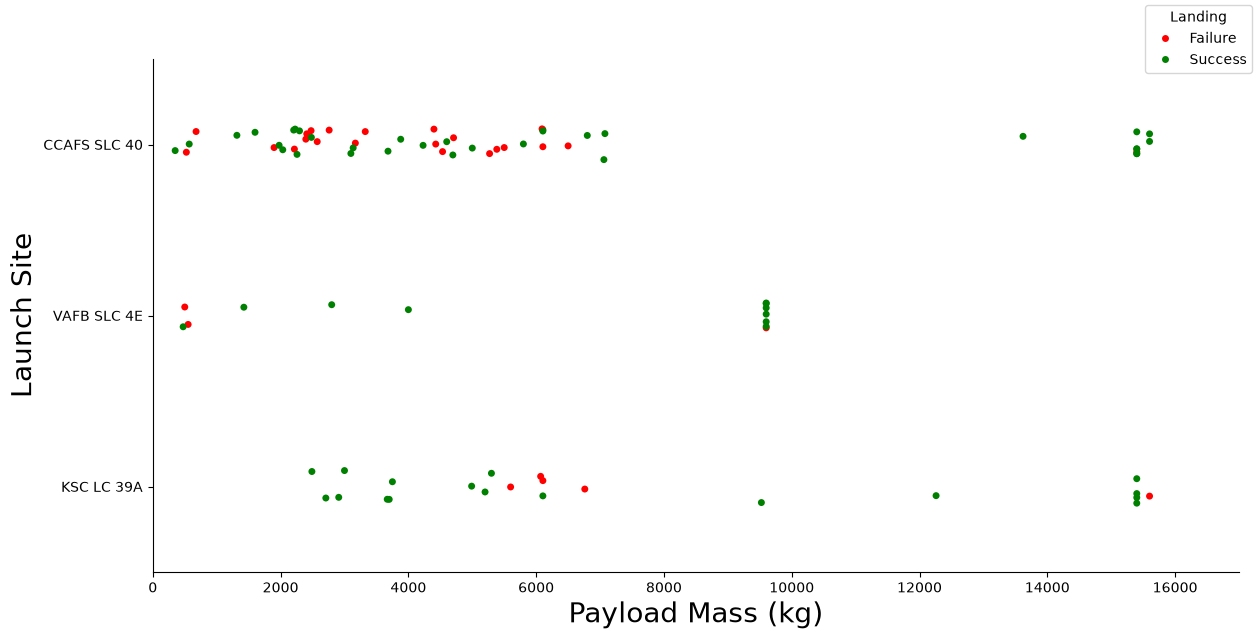

In [8]:
fig3 = sns.catplot(df, x='PayloadMass', y='LaunchSite', hue='Class', height=6, aspect=2, palette=['red', 'green'])
fig3.set_xlabels("Payload Mass (kg)",fontsize=20)
fig3.set_ylabels("Launch Site",fontsize=20)
fig3._legend.set_title('Landing')
fig3._legend.texts[0].set_text('Failure')
fig3._legend.texts[1].set_text('Success')
fig3._legend.set_bbox_to_anchor((1,1))
fig3._legend.set_loc('center right')
fig3._legend.set_frame_on(True)
plt.xlim(0,17000)
plt.tight_layout()

#### Observations

- Most launch attempts resulted in **successful landings** (green points).
- **CCAFS SLC 40** has the highest number of recorded launches.
- Payload masses vary significantly, ranging from a few hundred kilograms to nearly **16,000 kg**.
- Failures are present across different payload ranges, with no obvious concentration at a specific payload mass.
- Heavy payload missions (around **15,000–16,000 kg**) are mostly associated with successful landings.

#### Key Insights

- Payload mass alone does **not** appear to determine landing success.
- Launch site activity differs, with **CCAFS SLC 40** handling the largest volume of missions.
- Successful landings are consistently observed across low, medium, and high payload ranges, suggesting that factors beyond payload mass likely influence mission outcomes.

#### 4. Flight Number Vs Orbit type

The following scatter plot illustrates the relationship between **flight number** and **orbit type**, with each point representing a mission and its corresponding landing outcome. By visualizing missions across different orbit destinations over time, we can explore how landing success has evolved and identify which orbit types are associated with more successful recoveries.

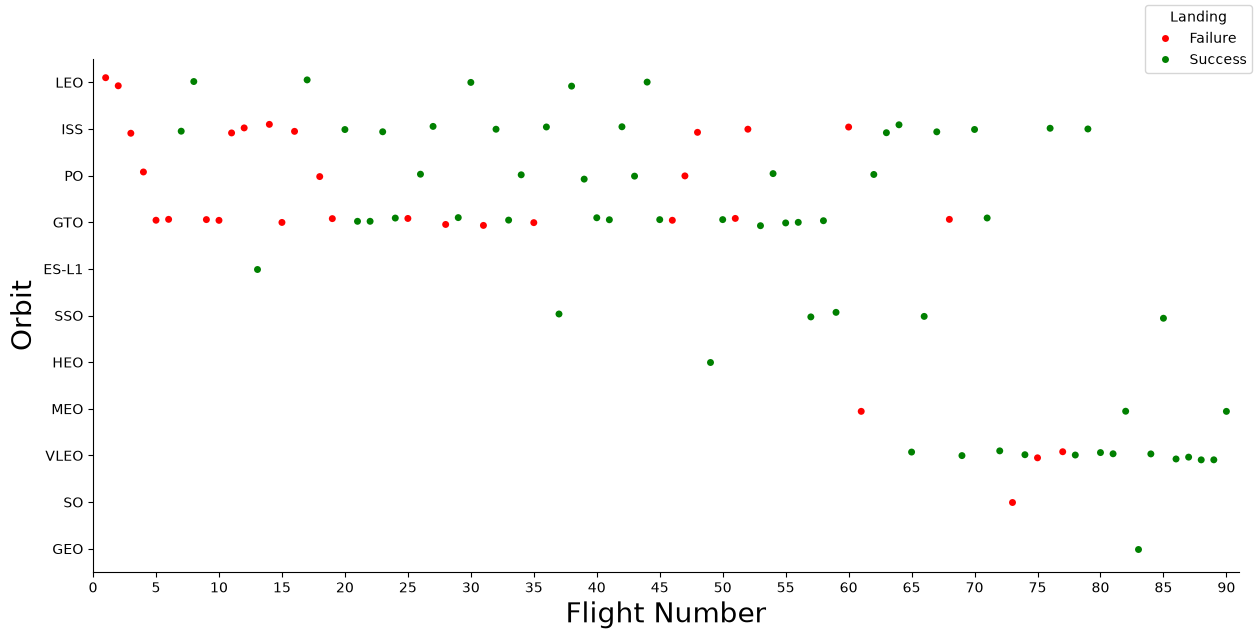

In [9]:
fig4 = sns.catplot(df, x='FlightNumber', y='Orbit', hue='Class', height=6, aspect=2, palette=['red', 'green'])
fig4.set_xlabels("Flight Number",fontsize=20)
fig4.set_ylabels("Orbit",fontsize=20)
fig4._legend.set_title('Landing')
fig4._legend.texts[0].set_text('Failure')
fig4._legend.texts[1].set_text('Success')
fig4._legend.set_bbox_to_anchor((1,1))
fig4._legend.set_loc('center right')
fig4._legend.set_frame_on(True)
plt.xlim(0,91)
plt.xticks(range(0,95, 5))
plt.tight_layout()

#### Observations

- Most missions across all orbit types resulted in **successful landings**.
- Early flights experienced a higher number of landing failures compared to later missions.
- **LEO**, **ISS**, and **GTO** missions account for a large share of the launches.
- Recent **VLEO** missions show a strong concentration of successful landings.

#### Insights

- Landing success improved over time, indicating increased reliability and operational experience.
- Missions to commonly targeted orbits, such as **LEO** and **ISS**, achieved consistently high success rates.
- Successful landings are observed across multiple orbit types, suggesting that orbit destination alone does not determine mission outcome.

#### 5. Payload Mass Vs Orbit type

The following scatter plot illustrates the relationship between **payload mass** and **orbit type**, with each point representing a mission and its corresponding landing outcome. By comparing payload masses across different orbit destinations, we can examine whether certain orbit types are associated with heavier payloads and explore if payload size influences landing success.

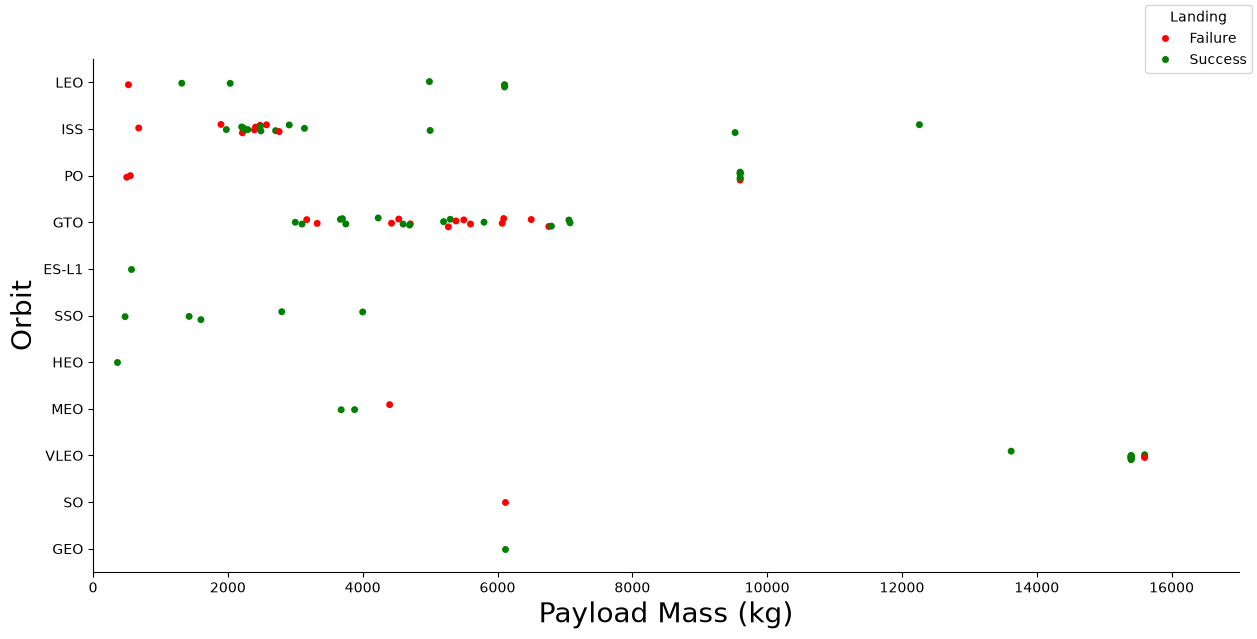

In [10]:
fig5 = sns.catplot(df, x='PayloadMass', y='Orbit', hue='Class', height=6, aspect=2, palette=['red', 'green'])
fig5.set_xlabels("Payload Mass (kg)",fontsize=20)
fig5.set_ylabels("Orbit",fontsize=20)
fig5._legend.set_title('Landing')
fig5._legend.texts[0].set_text('Failure')
fig5._legend.texts[1].set_text('Success')
fig5._legend.set_bbox_to_anchor((1,1))
fig5._legend.set_loc('center right')
fig5._legend.set_frame_on(True)
plt.xlim(0,17000)
plt.tight_layout()

#### Observations

- Most missions across different orbit types resulted in **successful landings**.
- **GTO** missions are concentrated in the **3,000–7,000 kg** payload range, with a mix of successful and failed landings.
- **VLEO** missions carried the heaviest payloads (around **14,000–16,000 kg**) and were predominantly successful.
- Lighter payload missions are distributed across multiple orbit types, including **LEO**, **ISS**, **SSO**, and **PO**.

#### Insights

- Payload mass does **not** show a clear correlation with landing success across orbit types.
- High-payload missions, particularly those targeting **VLEO**, achieved consistently successful landings.
- Orbit type and payload mass alone are insufficient to explain landing outcomes, suggesting that other mission and operational factors play a significant role.

#### 6. Orbit Type Vs Success Rate

The following bar chart shows the **landing success rate for each orbit type**, allowing us to compare mission performance across different orbital destinations. By analyzing the success percentages, we can identify which orbit types achieved the most reliable landings and where recovery performance was comparatively lower.

Text(0, 0.5, 'Success Rate %')

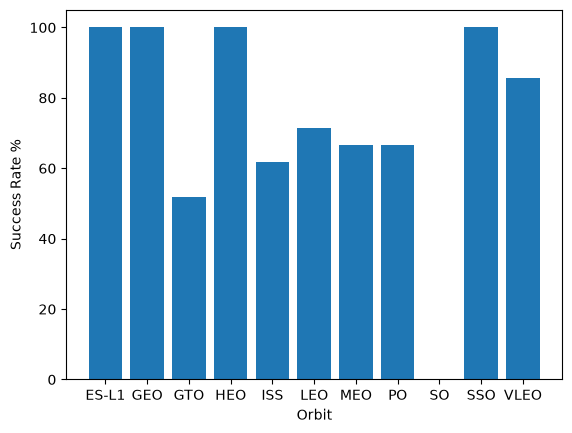

In [11]:
orbit_success_rate = df.groupby('Orbit')['Class'].mean().reset_index()
plt.bar(orbit_success_rate['Orbit'], height=orbit_success_rate['Class']*100)
plt.xlabel('Orbit')
plt.ylabel('Success Rate %')

#### Observations

- **ES-L1**, **GEO**, **HEO**, and **SSO** achieved a **100% landing success rate**.
- **VLEO** also recorded a high success rate of approximately **85%**.
- **LEO**, **MEO**, and **PO** maintained moderate success rates between **65% and 75%**.
- **SO** recorded a **0% landing success rate**, while **GTO** achieved a success rate of just above **50%**.

#### Insights

- Several orbit types demonstrate consistently successful recoveries, indicating strong landing reliability.
- **SO** had the lowest observed success rate; however, this result may be influenced by a very small number of missions.
- Overall, most orbit categories achieved moderate to high landing success rates, reflecting improved recovery capabilities across different mission profiles.

#### 7. Year Vs Success Rate

The following line chart illustrates the **annual landing success rate** over time. By tracking success rates across the years, we can observe how landing performance has evolved and identify periods of significant improvement in mission reliability.

Text(0, 0.5, 'Success rate %')

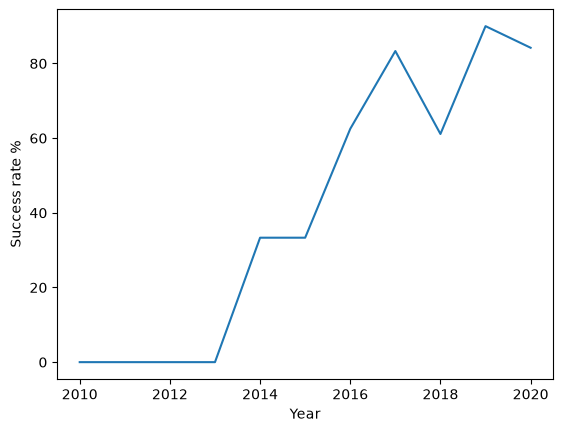

In [12]:
yearly_success = df.groupby("Year")['Class'].mean().reset_index()
plt.plot(yearly_success['Year'], yearly_success['Class']*100)
plt.xlabel('Year')
plt.ylabel('Success rate %')

#### Observations

- From **2010 to 2013**, the landing success rate remained at **0%**.
- Success rates began improving in **2014**, reaching approximately above **30%**.
- A significant increase occurred between **2015 and 2017**, with the success rate exceeding **80%**.
- Although there was a slight decline in **2018**, the success rate rebounded to nearly **90%** in **2019** and remained above **80%** in **2020**.

#### Insights

- Landing success improved steadily over the years, reflecting continuous advancements in landing technology and operational experience.
- The sharp increase after **2015** indicates a major improvement in mission reliability.
- Despite minor year-to-year fluctuations, the consistently high success rates in recent years demonstrate a mature and reliable landing system.

#### 8. Grid Fins, Reused Boosters, Legs Vs Landing Success Rate

The following bar charts compare the **landing success rate** based on three booster recovery features: **GridFins**, **Reused**, and **Legs**. By comparing missions with and without these features, we can understand how each contributes to successful booster landings.

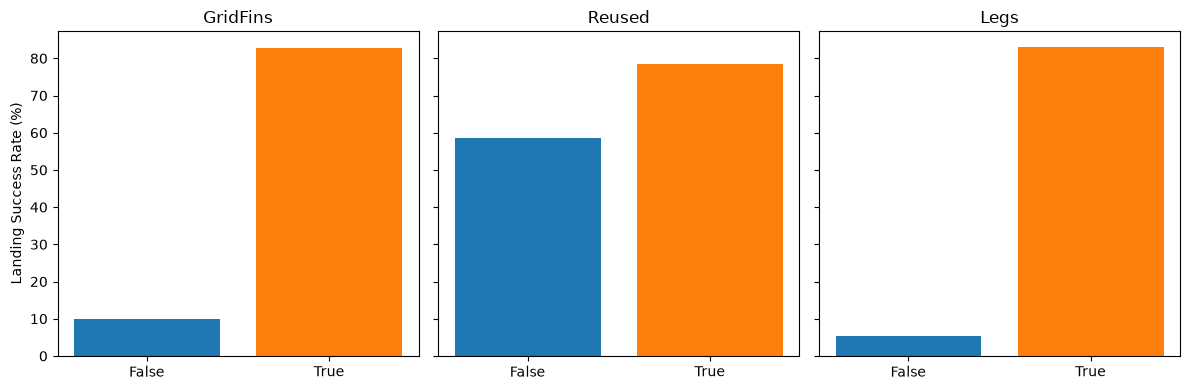

In [13]:
g1=(df.groupby('GridFins')['Class'].mean()*100).reset_index()
g2=(df.groupby('Reused')['Class'].mean()*100).reset_index()
g3=(df.groupby('Legs')['Class'].mean()*100).reset_index()
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

colors = ['tab:blue', 'tab:orange']

ax[0].bar(g1['GridFins'], g1['Class'], color=colors)
ax[0].set_title('GridFins')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['False', 'True'])

ax[1].bar(g2['Reused'], g2['Class'], color=colors)
ax[1].set_title('Reused')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['False', 'True'])

ax[2].bar(g3['Legs'], g3['Class'], color=colors)
ax[2].set_title('Legs')
ax[2].set_xticks([0, 1])
ax[2].set_xticklabels(['False', 'True'])

ax[0].set_ylabel('Landing Success Rate (%)')

plt.tight_layout()
plt.show()

#### Observations

- Missions using **GridFins** achieved a landing success rate of over **80%**, compared to around **10%** without them.
- **Reused** boosters recorded a higher success rate (approximately **78%**) than boosters flown for the first time (around **59%**).
- Missions with **Landing Legs** showed a success rate above **80%**, while those without legs had a success rate of only about **5%**.

#### Insights

- The presence of **GridFins** and **Landing Legs** is strongly associated with higher landing success rates.
- **Booster reuse** also correlates with improved landing performance, suggesting increased reliability through operational experience.
- Overall, recovery technologies and booster reusability appear to play a significant role in achieving successful landings.

## Data Preprocessing
- Before training the machine learning models, the dataset is prepared by selecting the relevant features and transforming them into a format suitable for model training.
- Since several features are categorical (such as `Orbit`, `LaunchSite`, and `LandingPad`), they are converted into numerical representations using one-hot encoding. The dataset is then split into training and testing sets to evaluate model performance on unseen data.
- For algorithms that rely on distance calculations or feature magnitudes, such as Logistic Regression, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN), feature scaling is applied using `StandardScaler` within a scikit-learn pipeline. Decision Trees are trained without feature scaling, as they are unaffected by differences in feature scales.

### Feature Encoding

Machine learning models require numerical input. Therefore, categorical variables are transformed into numerical features using one-hot encoding while preserving the information contained in each category.

In [14]:
# df[['FlightNumber', 'PayloadMass', 'Outcome', 'ReusedCount', 'Block', 'GridFins', 'Reused', 'Legs',]]
one_hot_df = pd.get_dummies(df[['LandingPad', 'Orbit', 'LaunchSite']], dtype=int)
features_one_hot = pd.concat([ df[['FlightNumber', 'PayloadMass', 'ReusedCount', 'Block', 'GridFins', 'Reused', 'Legs',]], one_hot_df], axis=1)
features_one_hot[['GridFins', 'Reused', 'Legs']]= features_one_hot[['GridFins', 'Reused', 'Legs']].astype(int)
features_one_hot.columns

Index(['FlightNumber', 'PayloadMass', 'ReusedCount', 'Block', 'GridFins',
       'Reused', 'Legs', 'LandingPad_5e9e3032383ecb267a34e7c7',
       'LandingPad_5e9e3032383ecb554034e7c9',
       'LandingPad_5e9e3032383ecb6bb234e7ca',
       'LandingPad_5e9e3032383ecb761634e7cb',
       'LandingPad_5e9e3033383ecbb9e534e7cc', 'Orbit_ES-L1', 'Orbit_GEO',
       'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS', 'Orbit_LEO', 'Orbit_MEO',
       'Orbit_PO', 'Orbit_SO', 'Orbit_SSO', 'Orbit_VLEO',
       'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A',
       'LaunchSite_VAFB SLC 4E'],
      dtype='str')

In [15]:
# features_one_hot.to_csv(r'data\\processed_data.csv', index=False)

In [16]:
X = features_one_hot
Y = df['Class']

### Train-Test Split

The processed dataset is divided into training and testing sets. The training data is used to build and tune the models, while the test data is reserved for evaluating how well the trained models generalize to unseen observations.

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f'Number of Test samples: {Y_test.shape[0]}')

Number of Test samples: 18


## Model 
The objective of this stage is to build a classification model capable of predicting whether the Falcon 9 first-stage booster will successfully land based on the mission characteristics.

To identify the most suitable algorithm, four supervised machine learning models are evaluated:

- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- K-Nearest Neighbors (KNN)

Each model is trained using a preprocessing pipeline, and its hyperparameters are optimized with `GridSearchCV` using cross-validation. This ensures that every classifier is evaluated under a consistent training procedure while identifying the best-performing parameter combination.

In [18]:
# Pipeline for Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])
param_grid_lr = {
    'lr__C':[0.01,0.1,1],
    'lr__penalty':['l2'],
    'lr__solver':['lbfgs']
}

# Pipeline for Support Vector Model (SVM)
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])
param_grid_svm = {
    'svc__kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
    'svc__C': np.logspace(-3, 3, 5),
    'svc__gamma':np.logspace(-3, 3, 5)
}

# Pipeline for Decision Tree
pipe_tree = Pipeline([
    ('tree', DecisionTreeClassifier(random_state=42))
])
param_grid_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__splitter': ['best', 'random'],
    'tree__max_depth': [2*n for n in range(1,10)],
    'tree__max_features': [None, 'sqrt'],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__min_samples_split': [2, 5, 10]
}

# Pipeline for K Nearest Neightbors (KNN)
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
param_grid_knn = {
    'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__p': [1,2]
}

To avoid repetitive code, a reusable helper function was implemented. The function performs hyperparameter tuning using GridSearchCV, evaluates the best estimator, and displays the confusion matrix along with key performance metrics (i.e.) accuracy.

In [19]:
def train_model(pipe, param_grid):
    model = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=10,
        scoring='accuracy',
        verbose=2
    )
    model.fit(X_train, Y_train)
    

    y_hat = model.predict(X_test)
    conf_matrix = confusion_matrix(Y_test, y_hat)

    sns.heatmap(conf_matrix, cmap='coolwarm', annot=True,
                xticklabels=['Did not land', 'Landed'],
                yticklabels=['Did not land', 'Landed'])
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()
    print(f'Best parameters: {model.best_params_}')
    print(f'Accuracy on Training data: {model.best_score_}')
    print(f'Accuracy on Test data: {model.score(X_test, Y_test)}')
    print('------------------------------------------------------------------------------------------------------------------')

Logistic Regression:
Fitting 10 folds for each of 3 candidates, totalling 30 fits
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ........lr__C=0.1,

d:\Trinita_CS\Daily practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Trinita_CS\Daily practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Trinita_CS\Daily practice\.venv\Lib\s

[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s
[CV] END ..........lr__C=1, lr__penalty=l2, lr__solver=lbfgs; total time=   0.0s


d:\Trinita_CS\Daily practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Trinita_CS\Daily practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Trinita_CS\Daily practice\.venv\Lib\s

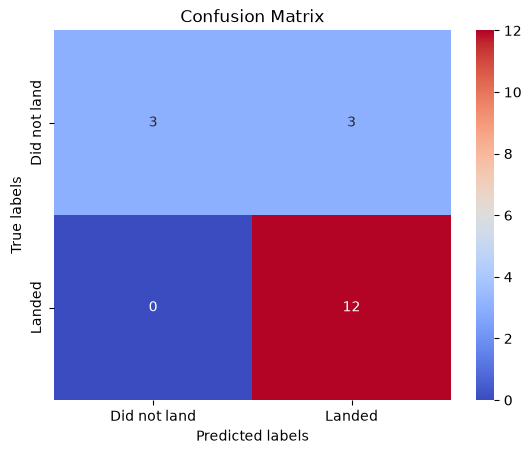

Best parameters: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Accuracy on Training data: 0.85
Accuracy on Test data: 0.8333333333333334
------------------------------------------------------------------------------------------------------------------
SVC:
Fitting 10 folds for each of 125 candidates, totalling 1250 fits
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=0.001, svc__gamma=0.001, svc__kernel=linear; total time=   0.0s
[CV] END .svc__C=

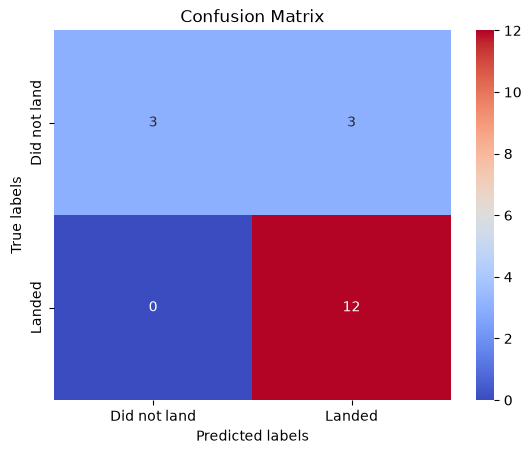

Best parameters: {'svc__C': np.float64(0.03162277660168379), 'svc__gamma': np.float64(0.001), 'svc__kernel': 'linear'}
Accuracy on Training data: 0.85
Accuracy on Test data: 0.8333333333333334
------------------------------------------------------------------------------------------------------------------
Decision Tree:
Fitting 10 folds for each of 648 candidates, totalling 6480 fits
[CV] END tree__criterion=gini, tree__max_depth=2, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2, tree__splitter=best; total time=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=2, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2, tree__splitter=best; total time=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=2, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2, tree__splitter=best; total time=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=2, tree__max_features=None, tree__min_samples_leaf=1, tree__m

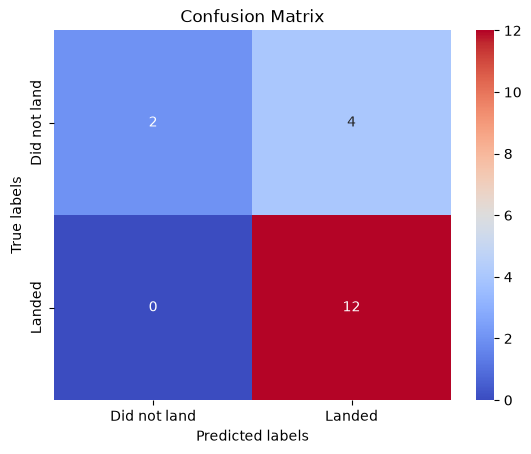

Best parameters: {'tree__criterion': 'gini', 'tree__max_depth': 2, 'tree__max_features': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2, 'tree__splitter': 'best'}
Accuracy on Training data: 0.8767857142857143
Accuracy on Test data: 0.7777777777777778
------------------------------------------------------------------------------------------------------------------
KNN:
Fitting 10 folds for each of 80 candidates, totalling 800 fits
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   2.1s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   0.0s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   0.0s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   0.0s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   0.0s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; total time=   0.0s
[CV] END ..knn__algorithm=auto, knn__n_neighbors=1, knn__p=1; t

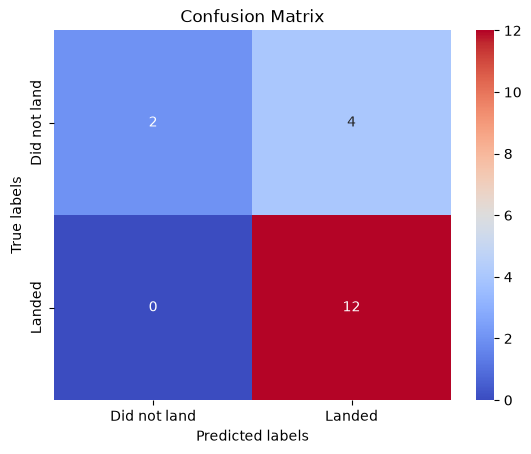

Best parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 5, 'knn__p': 2}
Accuracy on Training data: 0.8642857142857142
Accuracy on Test data: 0.7777777777777778
------------------------------------------------------------------------------------------------------------------


In [20]:
print('Logistic Regression:')
train_model(pipe_lr, param_grid_lr)

print('SVC:')
train_model(pipe_svm, param_grid_svm)

print('Decision Tree:')
train_model(pipe_tree, param_grid_tree)

print('KNN:')
train_model(pipe_knn, param_grid_knn)

#### Model Performance
|Model Accuracy|Train Accuracy|Test Accuracy|
|---|---|---|
|Logistic regression|85%|83.3%|
|SVC|85%|83.3%|
|Decision Tree|87.7%|77.8%|
|KNN|86.4%|77.8%|

- **Logistic Regression:** Good generalization (85% train, 83.3% test) with 0 false negatives and 3 false positives.
- **SVC:** Performed identically to Logistic Regression, showing stable and reliable classification (0 FN, 3 FP).
- **Decision Tree:** Highest training accuracy (87.7%) but lower test accuracy (77.8%), indicating slight overfitting (0 FN, 4 FP).
- **KNN:** Similar to Decision Tree with 86.4% train and 77.8% test accuracy, showing slightly weaker generalization (0 FN, 4 FP).

**Overall:** Logistic Regression and SVC achieved the best overall performance and generalization.